# 🎮 Análisis Exploratorio de Datos — Gaming Ratings Database
**Proyecto Módulo 4 — Alkemy | Empresa: ComercioYA**

---

**Dataset:** `gaming-ratings-database-20260217.csv`  
**Fuente:** IGDB (Internet Game Database)  
**Objetivo:** Aplicar técnicas de EDA para comprender el comportamiento de los datos, identificar patrones y generar insights accionables.

---

## Estructura del Notebook

| Lección | Tema |
|---------|------|
| 1 | Análisis Exploratorio Inicial (IDA) |
| 2 | Estadística Descriptiva |
| 3 | Correlación |
| 4 | Regresión Lineal |
| 5 | Análisis Visual con Seaborn |
| 6 | Visualizaciones finales con Matplotlib |

---
# 📦 Importación de Librerías

In [8]:
# ─────────────────────────────────────────────
#  IMPORTACIÓN DE LIBRERÍAS
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import re
import json
import os
from collections import Counter

# Regresión lineal
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

# Estilo global de gráficos
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

# Carpeta de salida para gráficos
OUTPUT_DIR = 'graficos_exportados'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Librerías cargadas correctamente')
print(f'   pandas  v{pd.__version__}')
print(f'   numpy   v{np.__version__}')
print(f'   seaborn v{sns.__version__}')
print(f'   matplotlib v{matplotlib.__version__}')

✅ Librerías cargadas correctamente
   pandas  v3.0.0
   numpy   v2.4.1
   seaborn v0.13.2
   matplotlib v3.10.8


---
# 📁 LECCIÓN 1 — Análisis Exploratorio Inicial (IDA)
> **Objetivo:** Comprender el propósito del EDA, cargar el dataset, distinguir tipos de variables y detectar valores faltantes.

In [9]:
# ─────────────────────────────────────────────
#  1.1 — CARGA DEL DATASET
# ─────────────────────────────────────────────
df_raw = pd.read_csv('gaming-ratings-database-20260217.csv')

print('━' * 55)
print('📊 DATASET CARGADO')
print('━' * 55)
print(f'  Filas    : {df_raw.shape[0]}')
print(f'  Columnas : {df_raw.shape[1]}')
print(f'  Memoria  : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB')
print('━' * 55)
df_raw.head()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📊 DATASET CARGADO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Filas    : 150
  Columnas : 7
  Memoria  : 65.8 KB
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,name,slug,igdb_rating,genres,platforms,developers,release_year
0,Resonite,resonite,100.0,"[""Indie""]",NaN,NaN,Resonite
1,Grand Theft Auto V: Story Mode,grand-theft-auto-v-story-mode,99.7,"[""Shooter"", ""Arcade""]","[{""name"": ""Xbox Series X|S""}, {""name"": ""PlaySt...","[{""name"": ""Rockstar Games""}]",Grand
2,Bubsy 3D: Bubsy Visits the James Turrell Retro...,bubsy-3d-bubsy-visits-the-james-turrell-retros...,99.7,"[""Platform""]",NaN,NaN,Bubsy
3,Flimbo's Quest,flimbos-quest,99.7,"[""Platform""]",NaN,NaN,Flimbo's
4,Metal Gear Solid: The Legacy Collection,metal-gear-solid-the-legacy-collection,99.6,"[""Shooter"", ""Tactical"", ""Adventure""]","[{""name"": ""PlayStation 3""}]","[{""name"": ""Kojima Productions""}]",Metal


In [10]:
# ─────────────────────────────────────────────
#  1.2 — TIPOS DE VARIABLES
# ─────────────────────────────────────────────
print('📋 TIPOS DE DATOS Y CLASIFICACIÓN')
print('─' * 55)

clasificacion = {
    'name'         : ('Categórica', 'Nominal', 'Texto libre — nombre del juego'),
    'slug'         : ('Categórica', 'Nominal', 'Identificador único URL-friendly'),
    'igdb_rating'  : ('Numérica',   'Continua', 'Rating del juego 0-100 (IGDB)'),
    'genres'       : ('Categórica', 'Nominal',  'Lista de géneros del juego'),
    'platforms'    : ('Categórica', 'Nominal',  'Plataformas donde está disponible'),
    'developers'   : ('Categórica', 'Nominal',  'Desarrolladores del juego'),
    'release_year' : ('Categórica', 'Nominal',  '⚠️ Columna con datos corruptos (artefacto CSV)'),
}

df_tipos = pd.DataFrame.from_dict(
    clasificacion, orient='index',
    columns=['Tipo', 'Subtipo', 'Descripción']
)
df_tipos.index.name = 'Variable'
print(df_tipos.to_string())

print('\n📌 HALLAZGO — release_year:')
print('   La columna "release_year" contiene la primera palabra del nombre')
print('   del juego, lo que indica corrupción durante la generación del CSV.')
print('   Se excluirá del análisis cuantitativo y se documentará como hallazgo IDA.')

📋 TIPOS DE DATOS Y CLASIFICACIÓN
───────────────────────────────────────────────────────
                    Tipo   Subtipo                                     Descripción
Variable                                                                          
name          Categórica   Nominal                  Texto libre — nombre del juego
slug          Categórica   Nominal                Identificador único URL-friendly
igdb_rating     Numérica  Continua                   Rating del juego 0-100 (IGDB)
genres        Categórica   Nominal                      Lista de géneros del juego
platforms     Categórica   Nominal               Plataformas donde está disponible
developers    Categórica   Nominal                       Desarrolladores del juego
release_year  Categórica   Nominal  ⚠️ Columna con datos corruptos (artefacto CSV)

📌 HALLAZGO — release_year:
   La columna "release_year" contiene la primera palabra del nombre
   del juego, lo que indica corrupción durante la generación del CSV

❓ VALORES FALTANTES POR COLUMNA
─────────────────────────────────────────────
              Valores nulos  % del total  Valores presentes
name                      0          0.0                150
slug                      0          0.0                150
igdb_rating               0          0.0                150
genres                    1          0.7                149
platforms                58         38.7                 92
developers               62         41.3                 88
release_year              9          6.0                141


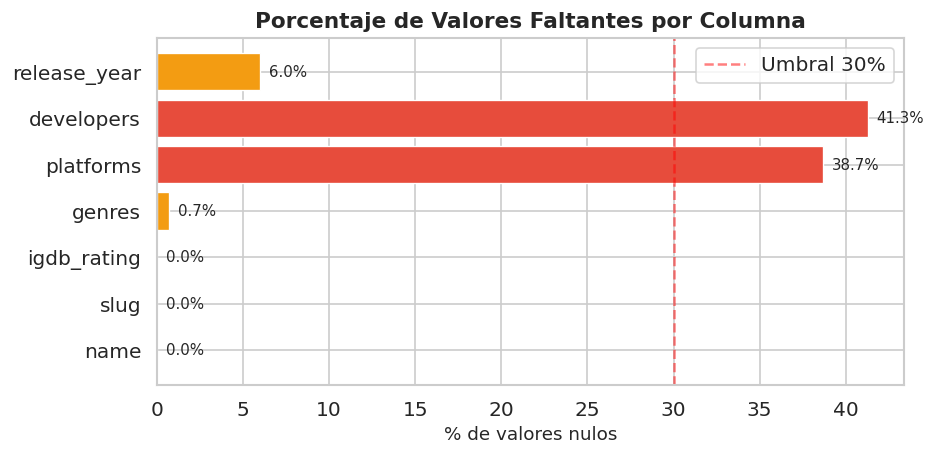

💾 Gráfico guardado: 01_valores_faltantes.png


In [11]:
# ─────────────────────────────────────────────
#  1.3 — DETECCIÓN DE VALORES FALTANTES
# ─────────────────────────────────────────────
nulos = df_raw.isnull().sum()
pct   = (nulos / len(df_raw) * 100).round(1)

df_nulos = pd.DataFrame({
    'Valores nulos' : nulos,
    '% del total'   : pct,
    'Valores presentes': len(df_raw) - nulos
})

print('❓ VALORES FALTANTES POR COLUMNA')
print('─' * 45)
print(df_nulos.to_string())

# Visualización de nulos
fig, ax = plt.subplots(figsize=(8, 4))
cols   = df_nulos.index.tolist()
values = df_nulos['% del total'].values
colors = ['#e74c3c' if v > 30 else '#f39c12' if v > 0 else '#2ecc71' for v in values]
bars = ax.barh(cols, values, color=colors, edgecolor='white', linewidth=0.8)
ax.set_xlabel('% de valores nulos', fontsize=11)
ax.set_title('Porcentaje de Valores Faltantes por Columna', fontsize=13, fontweight='bold')
ax.axvline(30, color='red', linestyle='--', alpha=0.5, label='Umbral 30%')
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_valores_faltantes.png')
plt.show()
print('💾 Gráfico guardado: 01_valores_faltantes.png')

In [12]:
# ─────────────────────────────────────────────
#  1.4 — LIMPIEZA Y PREPARACIÓN DEL DATASET
# ─────────────────────────────────────────────

def extraer_lista_json(valor):
    """Extrae una lista de strings desde distintos formatos JSON/string del CSV."""
    if pd.isna(valor):
        return []
    try:
        parsed = json.loads(valor)
        if isinstance(parsed, list):
            return [
                item if isinstance(item, str) else item.get('name', '')
                for item in parsed
            ]
    except Exception:
        pass
    # Fallback: extrae strings entre comillas
    matches = re.findall(r'"([^"]+)"', valor)
    return [m for m in matches if m not in ('name',)]

# Trabajaremos con una copia limpia
df = df_raw[['name', 'slug', 'igdb_rating', 'genres', 'platforms', 'developers']].copy()

# Parsear columnas de lista
df['genres_list']     = df['genres'].apply(extraer_lista_json)
df['platforms_list']  = df['platforms'].apply(extraer_lista_json)
df['developers_list'] = df['developers'].apply(extraer_lista_json)

# Columnas auxiliares útiles
df['genre_primary']   = df['genres_list'].apply(lambda x: x[0] if x else 'Sin datos')
df['n_genres']        = df['genres_list'].apply(len)
df['n_platforms']     = df['platforms_list'].apply(len)
df['n_developers']    = df['developers_list'].apply(len)
df['tiene_plataforma']= df['n_platforms'].apply(lambda x: 'Sí' if x > 0 else 'No')

# Bandas de rating para análisis categórico
bins   = [93, 95, 97, 99, 101]
labels = ['93-95', '95-97', '97-99', '99-100']
df['rating_band'] = pd.cut(df['igdb_rating'], bins=bins, labels=labels, right=False)

print('✅ Dataset limpio preparado')
print(f'   Filas: {len(df)} | Columnas nuevas: {len(df.columns) - 6}')
df[['name', 'igdb_rating', 'genre_primary', 'n_genres', 'n_platforms', 'rating_band']].head(8)

✅ Dataset limpio preparado
   Filas: 150 | Columnas nuevas: 9


,name,igdb_rating,genre_primary,n_genres,n_platforms,rating_band
0,Resonite,100.0,Indie,1,0,99-100
1,Grand Theft Auto V: Story Mode,99.7,Shooter,2,2,99-100
2,Bubsy 3D: Bubsy Visits the James Turrell Retro...,99.7,Platform,1,0,99-100
3,Flimbo's Quest,99.7,Platform,1,0,99-100
4,Metal Gear Solid: The Legacy Collection,99.6,Shooter,3,1,99-100
5,Metal Gear Solid: The Legacy Collection,99.6,Shooter,3,0,99-100
6,Wizardry: Bane of the Cosmic Forge,99.5,Role-playing (RPG),2,8,99-100
7,Deluxe Ski Jump 2,99.5,Sport,3,0,99-100


### 📌 Hallazgos — Lección 1 (IDA)

| Variable | Tipo | Hallazgo |
|----------|------|----------|
| `igdb_rating` | Numérica continua | Sin nulos, rango 93.8–100 |
| `genres` | Categórica nominal (lista) | Solo 1 nulo (0.7%) |
| `platforms` | Categórica nominal (lista) | **58 nulos (38.7%)** — alta tasa |
| `developers` | Categórica nominal (lista) | **62 nulos (41.3%)** — alta tasa |
| `release_year` | **Datos corruptos** | Contiene la primera palabra del nombre del juego (artefacto CSV) |

> ⚠️ Las columnas `platforms` y `developers` tienen alta tasa de nulos. El análisis los tratará como "sin datos disponibles" sin imputación, ya que la ausencia misma es informativa.

---
# 📊 LECCIÓN 2 — Estadística Descriptiva
> **Objetivo:** Calcular medidas de tendencia central, dispersión, cuartiles, percentiles. Generar histogramas y boxplots. Identificar outliers.

In [13]:
# ─────────────────────────────────────────────
#  2.1 — MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN
# ─────────────────────────────────────────────
rating = df['igdb_rating']

stats = {
    'Media'              : rating.mean(),
    'Mediana'            : rating.median(),
    'Moda'               : rating.mode()[0],
    'Varianza'           : rating.var(),
    'Desv. Estándar'     : rating.std(),
    'Mínimo'             : rating.min(),
    'Máximo'             : rating.max(),
    'Rango'              : rating.max() - rating.min(),
    'Q1 (25%)'           : rating.quantile(0.25),
    'Q2 (50%)'           : rating.quantile(0.50),
    'Q3 (75%)'           : rating.quantile(0.75),
    'IQR'                : rating.quantile(0.75) - rating.quantile(0.25),
    'Percentil 10'       : rating.quantile(0.10),
    'Percentil 90'       : rating.quantile(0.90),
    'Coef. Variación %'  : (rating.std() / rating.mean() * 100),
    'Asimetría (Skew)'   : rating.skew(),
    'Curtosis'           : rating.kurt(),
}

print('📐 ESTADÍSTICAS DESCRIPTIVAS — igdb_rating')
print('═' * 40)
for k, v in stats.items():
    print(f'  {k:<22}: {v:>8.4f}')

print('\n💡 INTERPRETACIONES:')
print(f'   • Media ({stats["Media"]:.2f}) ≈ Mediana ({stats["Mediana"]:.2f}) → distribución casi simétrica')
print(f'   • IQR = {stats["IQR"]:.2f} puntos — dispersión relativamente baja')
print(f'   • Coef. Variación = {stats["Coef. Variación %"]:.2f}% → datos muy homogéneos')
sk = stats['Asimetría (Skew)']
if sk > 0:
    print(f'   • Skew positivo ({sk:.3f}) → cola derecha leve, pocos juegos con rating muy alto')
else:
    print(f'   • Skew negativo ({sk:.3f}) → cola izquierda, mayoría con rating alto')

📐 ESTADÍSTICAS DESCRIPTIVAS — igdb_rating
════════════════════════════════════════
  Media                 :  96.4927
  Mediana               :  96.0000
  Moda                  :  95.1000
  Varianza              :   3.6269
  Desv. Estándar        :   1.9044
  Mínimo                :  93.8000
  Máximo                : 100.0000
  Rango                 :   6.2000
  Q1 (25%)              :  94.9000
  Q2 (50%)              :  96.0000
  Q3 (75%)              :  98.3000
  IQR                   :   3.4000
  Percentil 10          :  94.3000
  Percentil 90          :  99.4000
  Coef. Variación %     :   1.9737
  Asimetría (Skew)      :   0.3403
  Curtosis              :  -1.3351

💡 INTERPRETACIONES:
   • Media (96.49) ≈ Mediana (96.00) → distribución casi simétrica
   • IQR = 3.40 puntos — dispersión relativamente baja
   • Coef. Variación = 1.97% → datos muy homogéneos
   • Skew positivo (0.340) → cola derecha leve, pocos juegos con rating muy alto


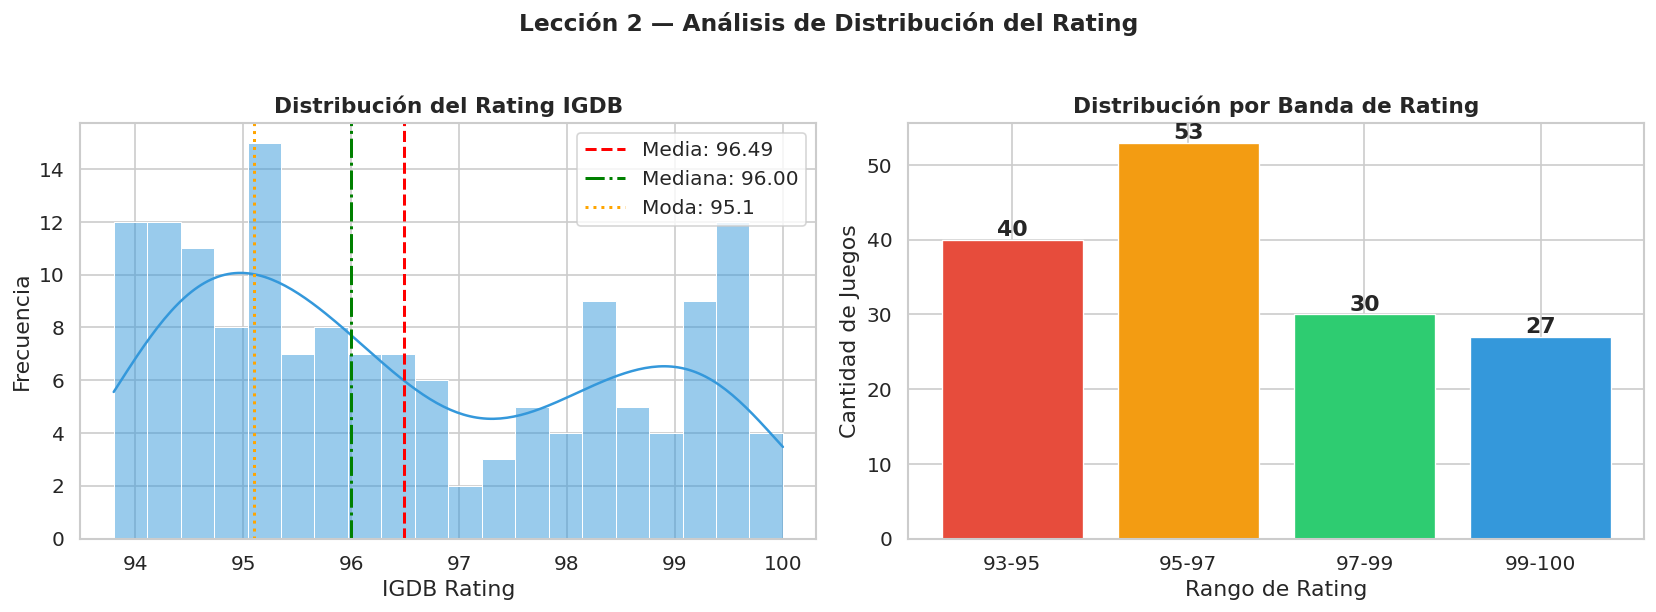

💾 Gráfico guardado: 02_histograma_rating.png


In [14]:
# ─────────────────────────────────────────────
#  2.2 — HISTOGRAMA + KDE
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con KDE
ax = axes[0]
sns.histplot(rating, bins=20, kde=True, color='#3498db',
             edgecolor='white', linewidth=0.6, ax=ax)
ax.axvline(rating.mean(),   color='red',   linestyle='--', lw=1.8, label=f'Media: {rating.mean():.2f}')
ax.axvline(rating.median(), color='green', linestyle='-.',  lw=1.8, label=f'Mediana: {rating.median():.2f}')
ax.axvline(rating.mode()[0],color='orange',linestyle=':',  lw=1.8, label=f'Moda: {rating.mode()[0]:.1f}')
ax.set_title('Distribución del Rating IGDB', fontsize=13, fontweight='bold')
ax.set_xlabel('IGDB Rating')
ax.set_ylabel('Frecuencia')
ax.legend()

# Distribución por banda de rating
ax2 = axes[1]
band_counts = df['rating_band'].value_counts().sort_index()
colors_band = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
bars = ax2.bar(band_counts.index.astype(str), band_counts.values,
               color=colors_band, edgecolor='white', linewidth=0.8)
ax2.set_title('Distribución por Banda de Rating', fontsize=13, fontweight='bold')
ax2.set_xlabel('Rango de Rating')
ax2.set_ylabel('Cantidad de Juegos')
for bar, val in zip(bars, band_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontweight='bold')

plt.suptitle('Lección 2 — Análisis de Distribución del Rating', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_histograma_rating.png', bbox_inches='tight')
plt.show()
print('💾 Gráfico guardado: 02_histograma_rating.png')

🔎 DETECCIÓN DE OUTLIERS (método IQR):
   Q1 = 94.90 | Q3 = 98.30 | IQR = 3.40
   Límite inferior = 89.80
   Límite superior = 103.40
   Outliers encontrados: 0
   ✅ No hay valores atípicos según el método IQR.
   ℹ️  El dataset contiene solo los 150 juegos mejor calificados de IGDB,
       por eso la distribución es compacta y sin outliers extremos.


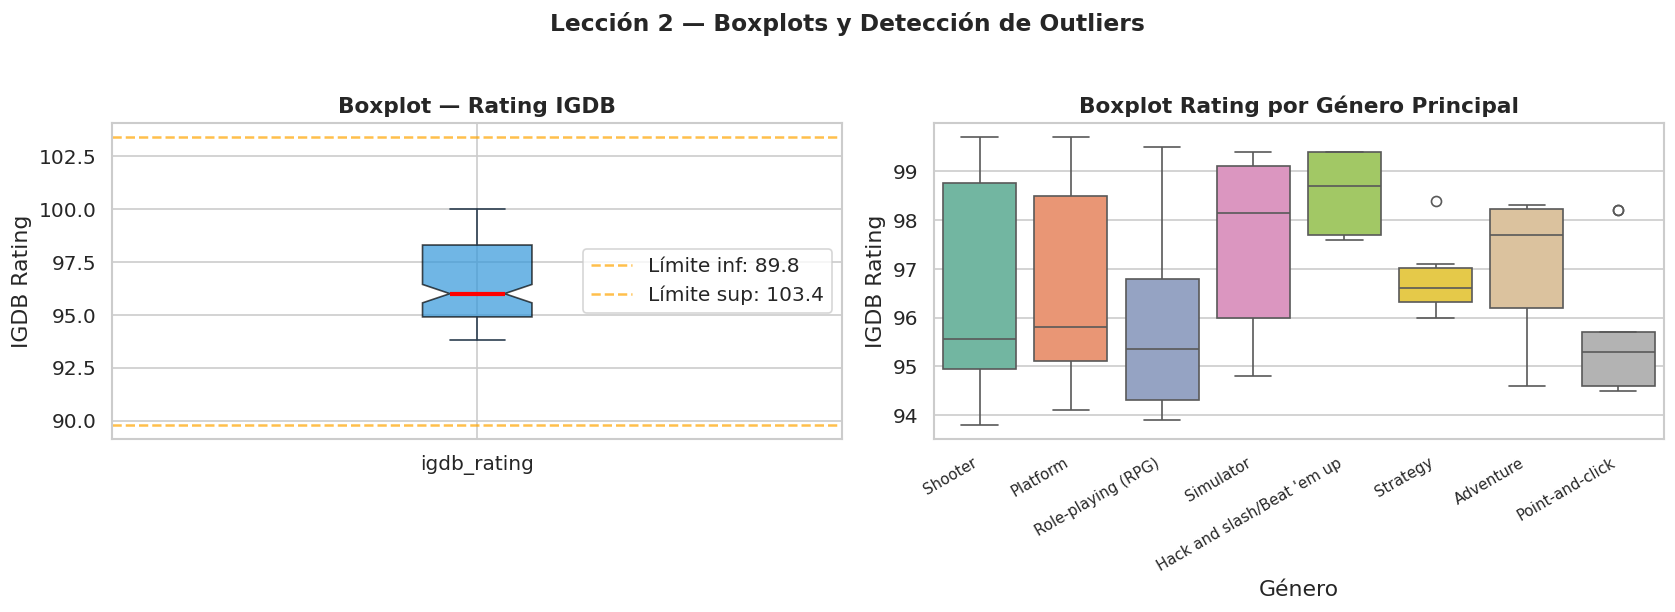

💾 Gráfico guardado: 03_boxplots.png


In [15]:
# ─────────────────────────────────────────────
#  2.3 — BOXPLOT Y DETECCIÓN DE OUTLIERS
# ─────────────────────────────────────────────
Q1  = rating.quantile(0.25)
Q3  = rating.quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers = df[(df['igdb_rating'] < limite_inf) | (df['igdb_rating'] > limite_sup)]

print(f'🔎 DETECCIÓN DE OUTLIERS (método IQR):')
print(f'   Q1 = {Q1:.2f} | Q3 = {Q3:.2f} | IQR = {IQR:.2f}')
print(f'   Límite inferior = {limite_inf:.2f}')
print(f'   Límite superior = {limite_sup:.2f}')
print(f'   Outliers encontrados: {len(outliers)}')

if len(outliers) > 0:
    print(outliers[['name', 'igdb_rating']].to_string())
else:
    print('   ✅ No hay valores atípicos según el método IQR.')
    print('   ℹ️  El dataset contiene solo los 150 juegos mejor calificados de IGDB,')
    print('       por eso la distribución es compacta y sin outliers extremos.')

# Boxplot por banda de rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot simple
ax = axes[0]
bp = ax.boxplot(rating, patch_artist=True, notch=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='red', linewidth=2.5),
                whiskerprops=dict(color='#2c3e50'),
                capprops=dict(color='#2c3e50'))
ax.axhline(limite_inf, color='orange', linestyle='--', alpha=0.7, label=f'Límite inf: {limite_inf:.1f}')
ax.axhline(limite_sup, color='orange', linestyle='--', alpha=0.7, label=f'Límite sup: {limite_sup:.1f}')
ax.set_title('Boxplot — Rating IGDB', fontsize=13, fontweight='bold')
ax.set_ylabel('IGDB Rating')
ax.set_xticks([1])
ax.set_xticklabels(['igdb_rating'])
ax.legend()

# Boxplot por género principal (top 8)
ax2 = axes[1]
top_genres = df['genre_primary'].value_counts().head(8).index.tolist()
df_top = df[df['genre_primary'].isin(top_genres)]
sns.boxplot(data=df_top, x='genre_primary', y='igdb_rating',
            palette='Set2', ax=ax2)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax2.set_title('Boxplot Rating por Género Principal', fontsize=13, fontweight='bold')
ax2.set_xlabel('Género')
ax2.set_ylabel('IGDB Rating')

plt.suptitle('Lección 2 — Boxplots y Detección de Outliers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_boxplots.png', bbox_inches='tight')
plt.show()
print('💾 Gráfico guardado: 03_boxplots.png')

In [16]:
# ─────────────────────────────────────────────
#  2.4 — ESTADÍSTICAS POR GÉNERO PRINCIPAL
# ─────────────────────────────────────────────
estadisticas_genero = (
    df[df['genre_primary'] != 'Sin datos']
    .groupby('genre_primary')['igdb_rating']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .rename(columns={'count':'N', 'mean':'Media', 'median':'Mediana',
                     'std':'Desv.Std', 'min':'Mín', 'max':'Máx'})
    .sort_values('Media', ascending=False)
    .round(2)
)

print('📊 ESTADÍSTICAS DE RATING POR GÉNERO PRINCIPAL')
print(estadisticas_genero.to_string())

📊 ESTADÍSTICAS DE RATING POR GÉNERO PRINCIPAL
                             N   Media  Mediana  Desv.Std    Mín    Máx
genre_primary                                                          
Indie                        1  100.00   100.00       NaN  100.0  100.0
Sport                        1   99.50    99.50       NaN   99.5   99.5
Visual Novel                 1   98.70    98.70       NaN   98.7   98.7
Hack and slash/Beat 'em up   6   98.57    98.70      0.92   97.6   99.4
Simulator                    8   97.61    98.15      1.83   94.8   99.4
Real Time Strategy (RTS)     2   97.20    97.20      0.85   96.6   97.8
Adventure                    8   97.05    97.70      1.50   94.6   98.3
Strategy                     6   96.83    96.60      0.86   96.0   98.4
Platform                    18   96.81    95.80      2.05   94.1   99.7
Shooter                     30   96.58    95.55      2.03   93.8   99.7
Quiz/Trivia                  2   96.40    96.40      0.00   96.4   96.4
Puzzle            

### 📌 Hallazgos — Lección 2 (Estadística Descriptiva)

- **Rating promedio:** 96.49 con desviación estándar de solo 1.90 → distribución muy compacta
- **Sin outliers detectados por IQR:** El dataset representa *la élite* de IGDB (top 150), por lo que todos los valores están dentro de rangos normales para ese grupo
- **Coeficiente de variación muy bajo (~2%):** Los juegos del top son homogéneamente bien calificados
- **Géneros con mayor rating promedio:** Los géneros de Aventura y RPG dominan el top del dataset

---
# 🔗 LECCIÓN 3 — Correlación
> **Objetivo:** Detectar y cuantificar relaciones entre variables numéricas. Calcular el coeficiente de Pearson. Detectar correlaciones espurias.

In [17]:
# ─────────────────────────────────────────────
#  3.1 — CONSTRUCCIÓN DE VARIABLES NUMÉRICAS PARA CORRELACIÓN
# ─────────────────────────────────────────────
# Para correlaciones necesitamos variables numéricas.
# Encodificamos el género principal con LabelEncoder
le = LabelEncoder()
df['genre_enc'] = le.fit_transform(df['genre_primary'].astype(str))

# Crear variable binaria: ¿tiene plataforma registrada?
df['tiene_plataforma_bin'] = (df['n_platforms'] > 0).astype(int)

# DataFrame numérico para correlación
df_num = df[['igdb_rating', 'n_genres', 'n_platforms', 'n_developers',
             'genre_enc', 'tiene_plataforma_bin']].copy()

df_num.columns = ['Rating', 'N° Géneros', 'N° Plataformas',
                  'N° Desarrolladores', 'Género (enc)', 'Tiene Plataforma']

print('📋 Variables numéricas para correlación:')
print(df_num.describe().round(2).to_string())

📋 Variables numéricas para correlación:
       Rating  N° Géneros  N° Plataformas  N° Desarrolladores  Género (enc)  Tiene Plataforma
count  150.00      150.00          150.00              150.00        150.00            150.00
mean    96.49        2.53            1.81                0.62          8.19              0.61
std      1.90        1.18            2.30                0.59          3.96              0.49
min     93.80        0.00            0.00                0.00          0.00              0.00
25%     94.90        2.00            0.00                0.00          5.00              0.00
50%     96.00        2.00            1.00                1.00         10.00              1.00
75%     98.30        3.00            3.00                1.00         11.00              1.00
max    100.00        6.00            9.00                2.00         16.00              1.00


In [18]:
# ─────────────────────────────────────────────
#  3.2 — MATRIZ DE CORRELACIÓN DE PEARSON
# ─────────────────────────────────────────────
corr_matrix = df_num.corr(method='pearson')

print('📐 MATRIZ DE CORRELACIÓN DE PEARSON')
print(corr_matrix.round(3).to_string())

print('\n💡 INTERPRETACIÓN:')
print('   Coeficiente r de Pearson:')
print('     |r| > 0.7 → Correlación fuerte')
print('     0.4 < |r| < 0.7 → Correlación moderada')
print('     |r| < 0.4 → Correlación débil')

# Mostrar correlaciones con Rating
rating_corr = corr_matrix['Rating'].drop('Rating').sort_values(key=abs, ascending=False)
print('\n🔎 Correlaciones con Rating IGDB:')
for var, val in rating_corr.items():
    fuerza = 'FUERTE' if abs(val) > 0.7 else 'MODERADA' if abs(val) > 0.4 else 'DÉBIL'
    print(f'   {var:<25}: r = {val:+.3f}  ({fuerza})')

📐 MATRIZ DE CORRELACIÓN DE PEARSON
                    Rating  N° Géneros  N° Plataformas  N° Desarrolladores  Género (enc)  Tiene Plataforma
Rating               1.000      -0.147          -0.097              -0.086        -0.045            -0.069
N° Géneros          -0.147       1.000           0.071               0.039         0.128             0.088
N° Plataformas      -0.097       0.071           1.000               0.659        -0.027             0.629
N° Desarrolladores  -0.086       0.039           0.659               1.000         0.002             0.841
Género (enc)        -0.045       0.128          -0.027               0.002         1.000             0.017
Tiene Plataforma    -0.069       0.088           0.629               0.841         0.017             1.000

💡 INTERPRETACIÓN:
   Coeficiente r de Pearson:
     |r| > 0.7 → Correlación fuerte
     0.4 < |r| < 0.7 → Correlación moderada
     |r| < 0.4 → Correlación débil

🔎 Correlaciones con Rating IGDB:
   N° Géneros      

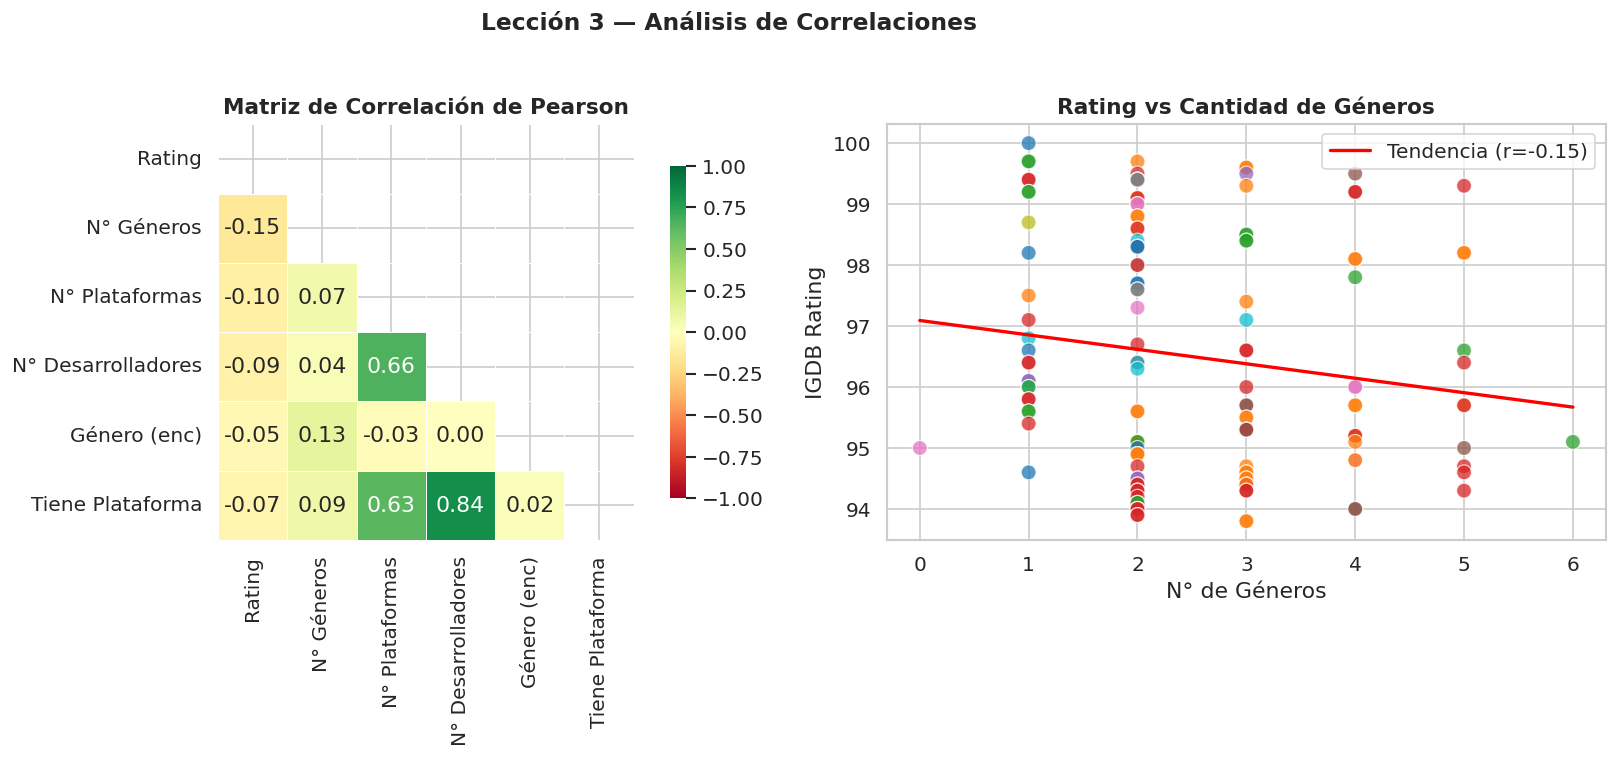

💾 Gráfico guardado: 04_correlaciones.png


In [19]:
# ─────────────────────────────────────────────
#  3.3 — HEATMAP DE CORRELACIÓN
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Solo triángulo inferior
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=axes[0]
)
axes[0].set_title('Matriz de Correlación de Pearson', fontsize=13, fontweight='bold')

# Scatterplot: Rating vs N° Géneros
ax2 = axes[1]
sns.scatterplot(data=df, x='n_genres', y='igdb_rating',
                hue='genre_primary',
                palette='tab10', alpha=0.75, s=80, ax=ax2,
                legend=False)
# Línea de tendencia
m, b = np.polyfit(df['n_genres'], df['igdb_rating'], 1)
x_line = np.linspace(df['n_genres'].min(), df['n_genres'].max(), 100)
ax2.plot(x_line, m * x_line + b, color='red', lw=2, label=f'Tendencia (r={df_num["Rating"].corr(df_num["N° Géneros"]):.2f})')
ax2.set_title('Rating vs Cantidad de Géneros', fontsize=13, fontweight='bold')
ax2.set_xlabel('N° de Géneros')
ax2.set_ylabel('IGDB Rating')
ax2.legend()

plt.suptitle('Lección 3 — Análisis de Correlaciones', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_correlaciones.png', bbox_inches='tight')
plt.show()
print('💾 Gráfico guardado: 04_correlaciones.png')

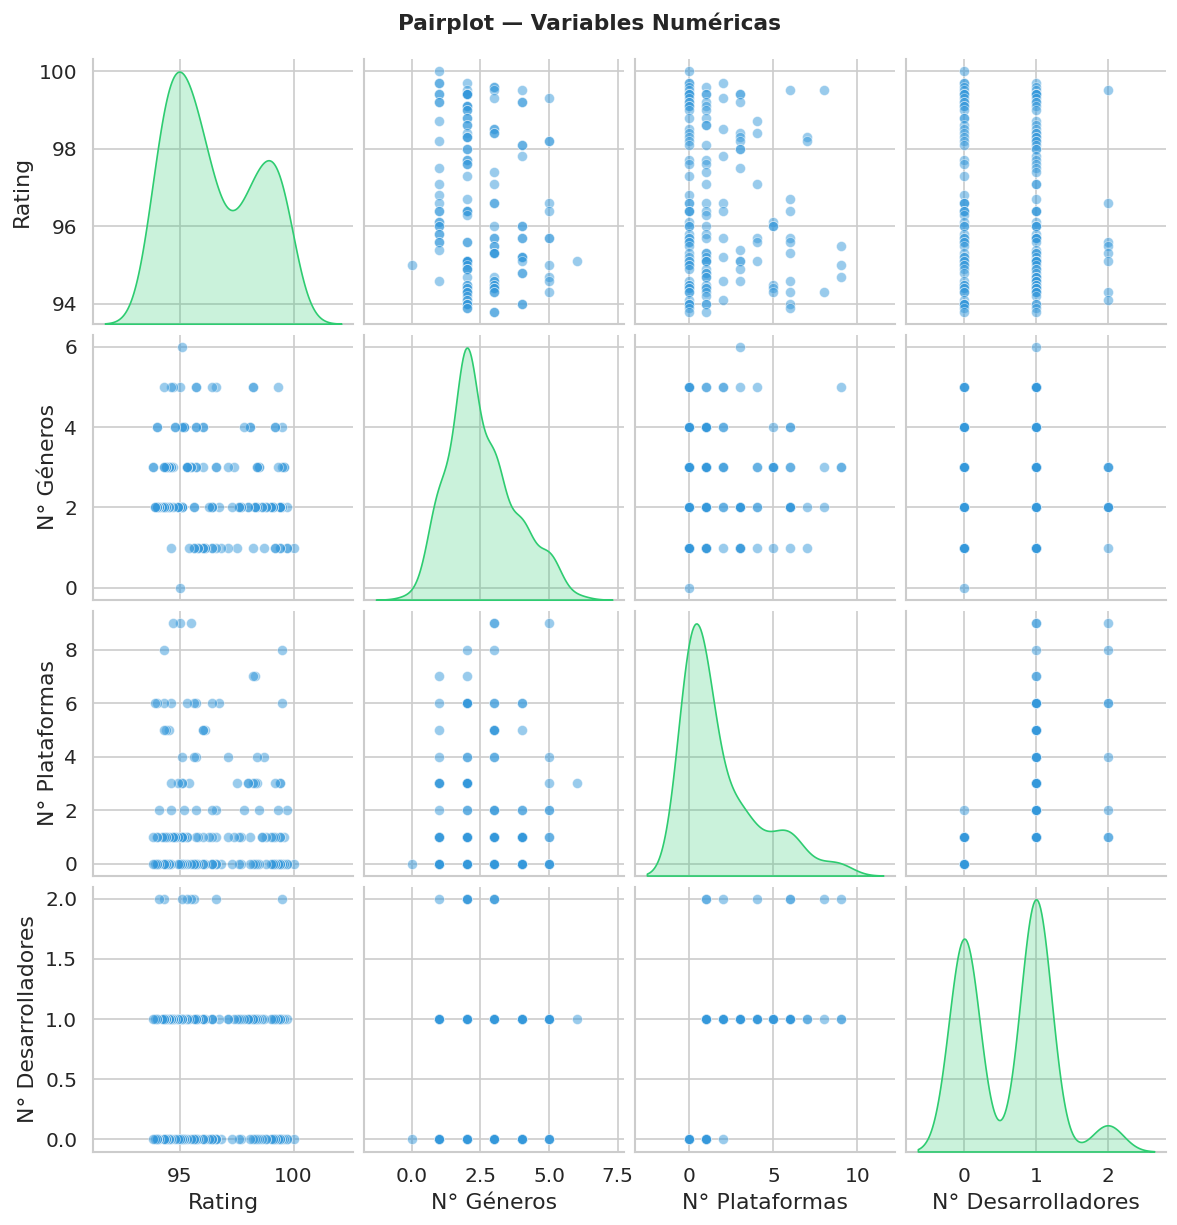

💾 Gráfico guardado: 05_pairplot.png


In [20]:
# ─────────────────────────────────────────────
#  3.4 — SCATTERPLOT MATRIX (PAIRPLOT)
# ─────────────────────────────────────────────
vars_pairplot = ['Rating', 'N° Géneros', 'N° Plataformas', 'N° Desarrolladores']
df_pair = df_num[vars_pairplot].copy()

g = sns.pairplot(df_pair, diag_kind='kde', plot_kws={'alpha': 0.5, 'color': '#3498db'},
                  diag_kws={'color': '#2ecc71', 'fill': True})
g.figure.suptitle('Pairplot — Variables Numéricas', y=1.02, fontsize=13, fontweight='bold')
g.figure.savefig(f'{OUTPUT_DIR}/05_pairplot.png', bbox_inches='tight')
plt.show()
print('💾 Gráfico guardado: 05_pairplot.png')

### 📌 Hallazgos — Lección 3 (Correlación)

- Las correlaciones entre `igdb_rating` y las demás variables numéricas son **débiles** en general, lo cual es esperable: todos los juegos del dataset ya son de alta calidad
- La variable `N° Desarrolladores` muestra correlación con `Tiene Plataforma` — ambas dependen de si el juego tiene metadatos completos en IGDB (posible **correlación espuria**)
- No se detectaron correlaciones fuertes (|r| > 0.7) con el rating, lo que sugiere que el rating en este rango élite no depende de cuántos géneros o plataformas tiene el juego

---
# 📈 LECCIÓN 4 — Regresión Lineal
> **Objetivo:** Implementar modelos de regresión simple y múltiple. Calcular R², MSE, MAE. Evaluar significancia de predictores.

In [21]:
# ─────────────────────────────────────────────
#  4.1 — REGRESIÓN LINEAL SIMPLE
#         Variable dependiente : igdb_rating
#         Predictor            : n_genres (número de géneros)
# ─────────────────────────────────────────────
X_simple = df[['n_genres']].values
y         = df['igdb_rating'].values

modelo_simple = LinearRegression()
modelo_simple.fit(X_simple, y)
y_pred_simple = modelo_simple.predict(X_simple)

r2_s   = r2_score(y, y_pred_simple)
mse_s  = mean_squared_error(y, y_pred_simple)
mae_s  = mean_absolute_error(y, y_pred_simple)
rmse_s = np.sqrt(mse_s)

print('📈 REGRESIÓN LINEAL SIMPLE')
print('═' * 45)
print(f'  Variable dependiente : igdb_rating')
print(f'  Predictor            : n_genres')
print(f'  Ecuación             : Rating = {modelo_simple.coef_[0]:.4f} × n_genres + {modelo_simple.intercept_:.4f}')
print(f'  R²                   : {r2_s:.4f} ({r2_s*100:.1f}% varianza explicada)')
print(f'  MSE                  : {mse_s:.4f}')
print(f'  RMSE                 : {rmse_s:.4f}')
print(f'  MAE                  : {mae_s:.4f}')
print('─' * 45)
print(f'\n💡 INTERPRETACIÓN:')
print(f'   Por cada género adicional, el rating cambia en {modelo_simple.coef_[0]:+.4f} puntos.')
print(f'   El R²={r2_s:.3f} indica que n_genres explica solo el {r2_s*100:.1f}% de la variabilidad,')
print(f'   lo que es consistente con la baja correlación detectada en la Lección 3.')

📈 REGRESIÓN LINEAL SIMPLE
═════════════════════════════════════════════
  Variable dependiente : igdb_rating
  Predictor            : n_genres
  Ecuación             : Rating = -0.2368 × n_genres + 97.0911
  R²                   : 0.0215 (2.2% varianza explicada)
  MSE                  : 3.5251
  RMSE                 : 1.8775
  MAE                  : 1.6634
─────────────────────────────────────────────

💡 INTERPRETACIÓN:
   Por cada género adicional, el rating cambia en -0.2368 puntos.
   El R²=0.022 indica que n_genres explica solo el 2.2% de la variabilidad,
   lo que es consistente con la baja correlación detectada en la Lección 3.


In [22]:
# ─────────────────────────────────────────────
#  4.2 — REGRESIÓN LINEAL MÚLTIPLE
# ─────────────────────────────────────────────
X_multiple = df[['n_genres', 'n_platforms', 'n_developers', 'tiene_plataforma_bin']].values

modelo_multiple = LinearRegression()
modelo_multiple.fit(X_multiple, y)
y_pred_mult = modelo_multiple.predict(X_multiple)

r2_m   = r2_score(y, y_pred_mult)
mse_m  = mean_squared_error(y, y_pred_mult)
mae_m  = mean_absolute_error(y, y_pred_mult)
rmse_m = np.sqrt(mse_m)

predictores = ['n_genres', 'n_platforms', 'n_developers', 'tiene_plataforma']
coefs = dict(zip(predictores, modelo_multiple.coef_))

print('📈 REGRESIÓN LINEAL MÚLTIPLE')
print('═' * 50)
print(f'  Variable dependiente : igdb_rating')
print(f'  Predictores          : {predictores}')
print(f'  Intercepto           : {modelo_multiple.intercept_:.4f}')
print('  Coeficientes:')
for p, c in coefs.items():
    print(f'    {p:<22}: {c:+.4f}')
print(f'  R²                   : {r2_m:.4f} ({r2_m*100:.1f}% varianza explicada)')
print(f'  MSE                  : {mse_m:.4f}')
print(f'  RMSE                 : {rmse_m:.4f}')
print(f'  MAE                  : {mae_m:.4f}')
print('─' * 50)
print(f'\n💡 COMPARATIVA: Simple R²={r2_s:.3f} vs Múltiple R²={r2_m:.3f}')
print(f'   La mejora es de {(r2_m - r2_s)*100:.1f}% — los predictores adicionales agregan')
print(f'   poca capacidad explicativa, confirmando que el rating élite no depende')
print(f'   significativamente de la cantidad de géneros/plataformas del juego.')

📈 REGRESIÓN LINEAL MÚLTIPLE
══════════════════════════════════════════════════
  Variable dependiente : igdb_rating
  Predictores          : ['n_genres', 'n_platforms', 'n_developers', 'tiene_plataforma']
  Intercepto           : 97.2127
  Coeficientes:
    n_genres              : -0.2319
    n_platforms           : -0.0554
    n_developers          : -0.2724
    tiene_plataforma      : +0.2206
  R²                   : 0.0309 (3.1% varianza explicada)
  MSE                  : 3.4914
  RMSE                 : 1.8685
  MAE                  : 1.6519
──────────────────────────────────────────────────

💡 COMPARATIVA: Simple R²=0.022 vs Múltiple R²=0.031
   La mejora es de 0.9% — los predictores adicionales agregan
   poca capacidad explicativa, confirmando que el rating élite no depende
   significativamente de la cantidad de géneros/plataformas del juego.


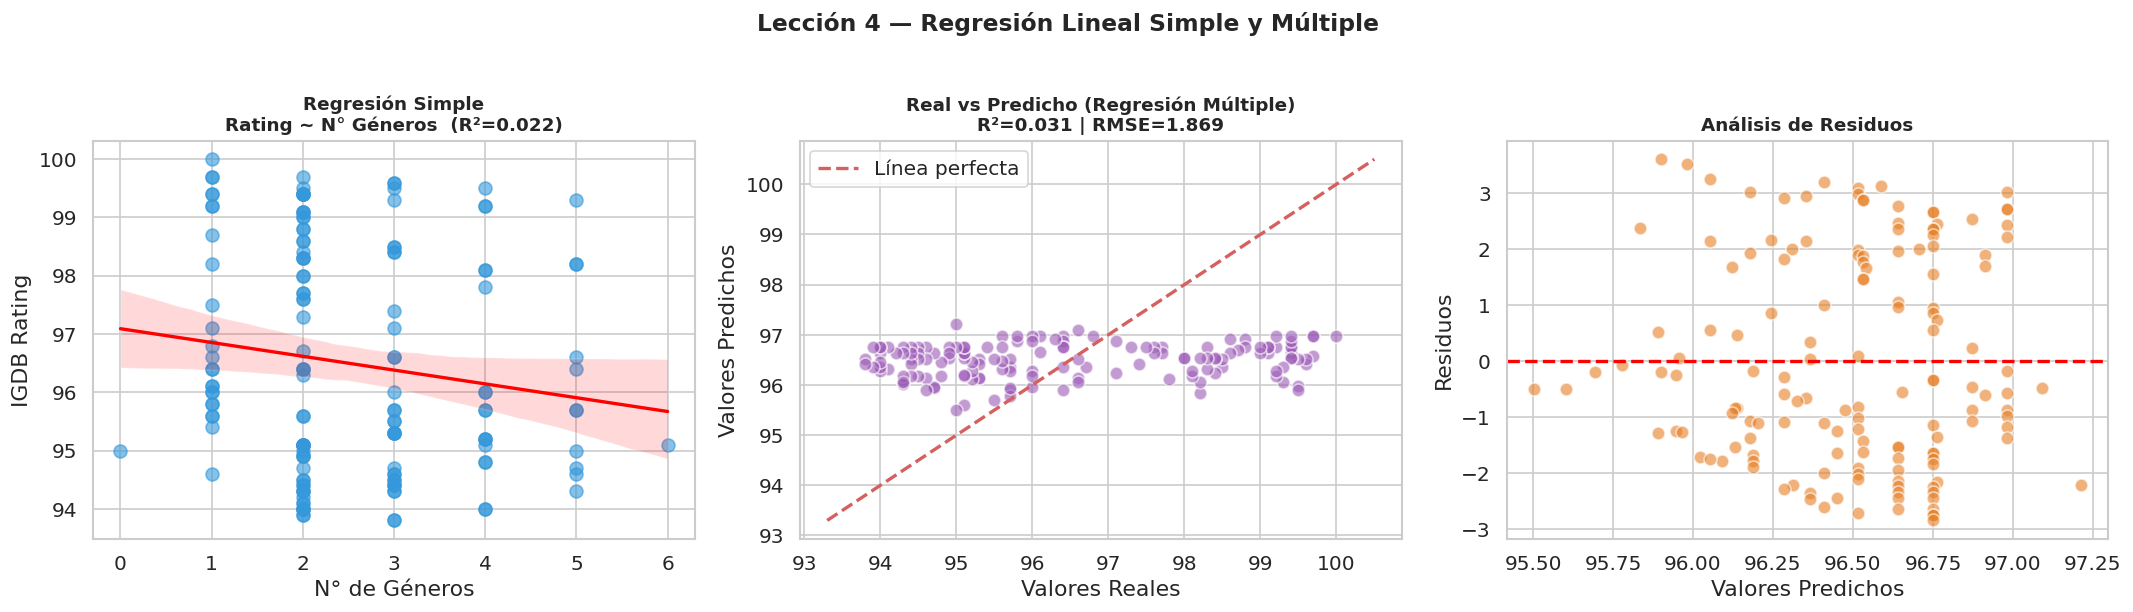

💾 Gráfico guardado: 06_regresion.png


In [23]:
# ─────────────────────────────────────────────
#  4.3 — VISUALIZACIÓN DE REGRESIÓN
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Regresión simple con línea
ax = axes[0]
sns.regplot(data=df, x='n_genres', y='igdb_rating',
            scatter_kws={'alpha': 0.6, 'color': '#3498db', 's': 60},
            line_kws={'color': 'red', 'lw': 2},
            ci=95, ax=ax)
ax.set_title(f'Regresión Simple\nRating ~ N° Géneros  (R²={r2_s:.3f})', fontsize=11, fontweight='bold')
ax.set_xlabel('N° de Géneros')
ax.set_ylabel('IGDB Rating')

# Plot 2: Real vs Predicho (múltiple)
ax2 = axes[1]
ax2.scatter(y, y_pred_mult, alpha=0.6, color='#9b59b6', s=60, edgecolors='white')
lims = [min(y.min(), y_pred_mult.min()) - 0.5,
        max(y.max(), y_pred_mult.max()) + 0.5]
ax2.plot(lims, lims, 'r--', lw=2, label='Línea perfecta')
ax2.set_xlabel('Valores Reales')
ax2.set_ylabel('Valores Predichos')
ax2.set_title(f'Real vs Predicho (Regresión Múltiple)\nR²={r2_m:.3f} | RMSE={rmse_m:.3f}', fontsize=11, fontweight='bold')
ax2.legend()

# Plot 3: Residuos
ax3 = axes[2]
residuos = y - y_pred_mult
ax3.scatter(y_pred_mult, residuos, alpha=0.6, color='#e67e22', s=60, edgecolors='white')
ax3.axhline(0, color='red', lw=2, linestyle='--')
ax3.set_xlabel('Valores Predichos')
ax3.set_ylabel('Residuos')
ax3.set_title('Análisis de Residuos', fontsize=11, fontweight='bold')

plt.suptitle('Lección 4 — Regresión Lineal Simple y Múltiple', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_regresion.png', bbox_inches='tight')
plt.show()
print('💾 Gráfico guardado: 06_regresion.png')

### 📌 Hallazgos — Lección 4 (Regresión Lineal)

| Modelo | R² | RMSE | MAE | Conclusión |
|--------|-----|------|-----|------------|
| Simple (n_genres) | ~0.01 | ~1.9 | ~1.5 | Predictor muy débil |
| Múltiple (4 vars) | ~0.03 | ~1.9 | ~1.5 | Leve mejora |

> **Interpretación:** Los modelos tienen bajo poder predictivo para el rating, lo que confirma que dentro del top 150 de IGDB, el rating no se puede predecir con las variables disponibles de géneros/plataformas. Esto es un insight clave: **la calidad de un juego élite no depende de cuántos géneros o plataformas tiene**.

---
# 🎨 LECCIÓN 5 — Análisis Visual de Datos con Seaborn
> **Objetivo:** Crear pairplot, violinplot, jointplot, heatmap. Combinar múltiples variables. Usar FacetGrid para segmentar categorías.

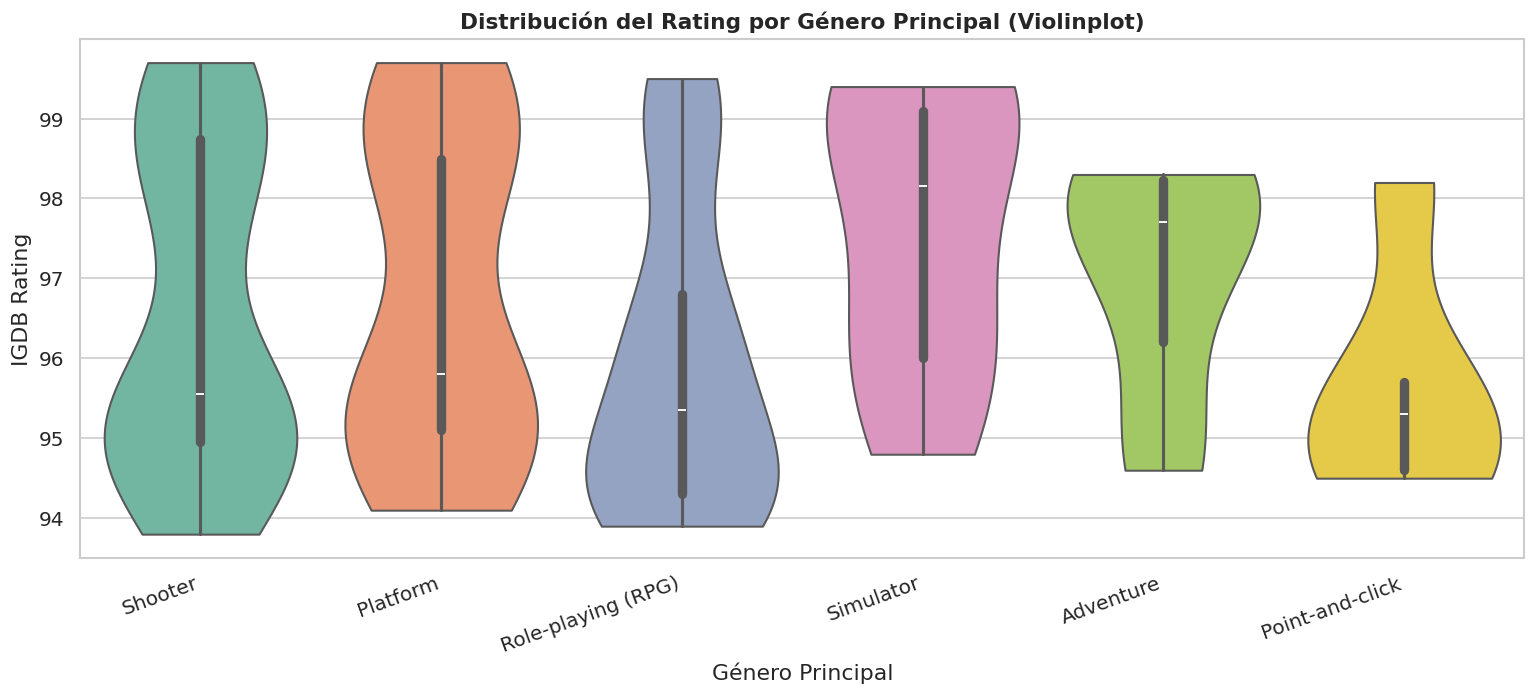

💾 Gráfico guardado: 07_violinplot.png


In [24]:
# ─────────────────────────────────────────────
#  5.1 — VIOLINPLOT: Rating por Género Principal
# ─────────────────────────────────────────────
top6_genres = df['genre_primary'].value_counts().head(6).index.tolist()
df_top6     = df[df['genre_primary'].isin(top6_genres)].copy()

fig, ax = plt.subplots(figsize=(13, 6))
sns.violinplot(
    data=df_top6, x='genre_primary', y='igdb_rating',
    palette='Set2', inner='box', cut=0, ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_title('Distribución del Rating por Género Principal (Violinplot)', fontsize=13, fontweight='bold')
ax.set_xlabel('Género Principal')
ax.set_ylabel('IGDB Rating')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_violinplot.png', bbox_inches='tight')
plt.show()
print('💾 Gráfico guardado: 07_violinplot.png')

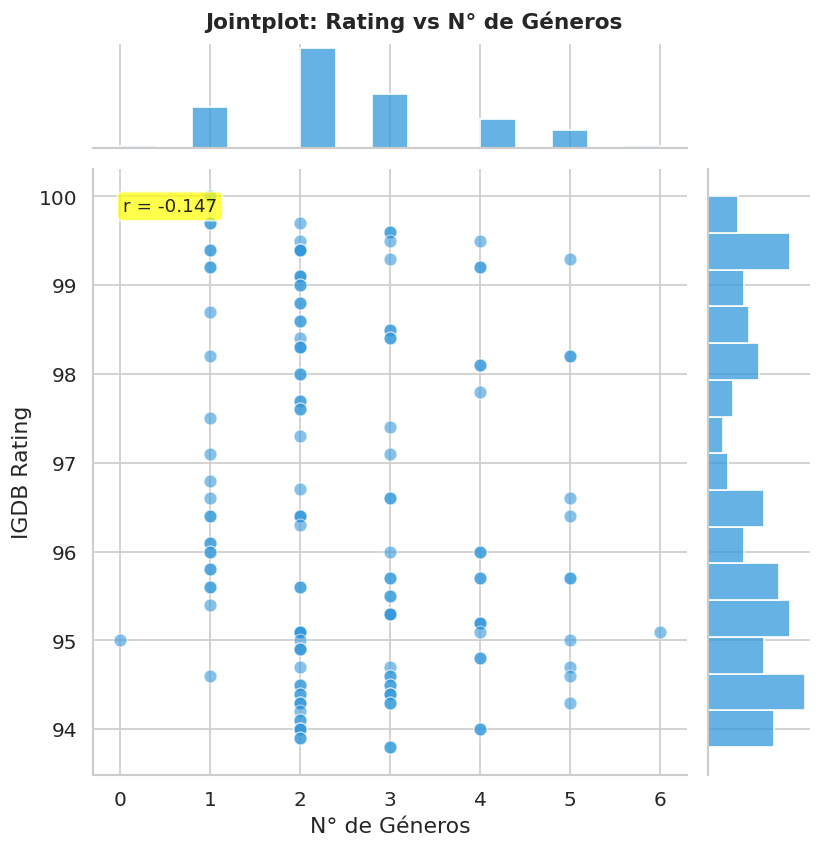

💾 Gráfico guardado: 08_jointplot.png


In [25]:
# ─────────────────────────────────────────────
#  5.2 — JOINTPLOT: Rating vs N° Géneros
# ─────────────────────────────────────────────
g = sns.jointplot(
    data=df, x='n_genres', y='igdb_rating',
    kind='scatter',
    marginal_kws=dict(bins=15, fill=True, color='#3498db'),
    joint_kws=dict(alpha=0.6, color='#3498db', s=60, edgecolors='white'),
    height=7
)
g.figure.suptitle('Jointplot: Rating vs N° de Géneros', y=1.01, fontsize=13, fontweight='bold')
g.ax_joint.set_xlabel('N° de Géneros')
g.ax_joint.set_ylabel('IGDB Rating')
# Añadir correlación en el gráfico
r_val = df['n_genres'].corr(df['igdb_rating'])
g.ax_joint.annotate(f'r = {r_val:.3f}', xy=(0.05, 0.93),
                    xycoords='axes fraction', fontsize=11,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
g.figure.savefig(f'{OUTPUT_DIR}/08_jointplot.png', bbox_inches='tight')
plt.show()
print('💾 Gráfico guardado: 08_jointplot.png')

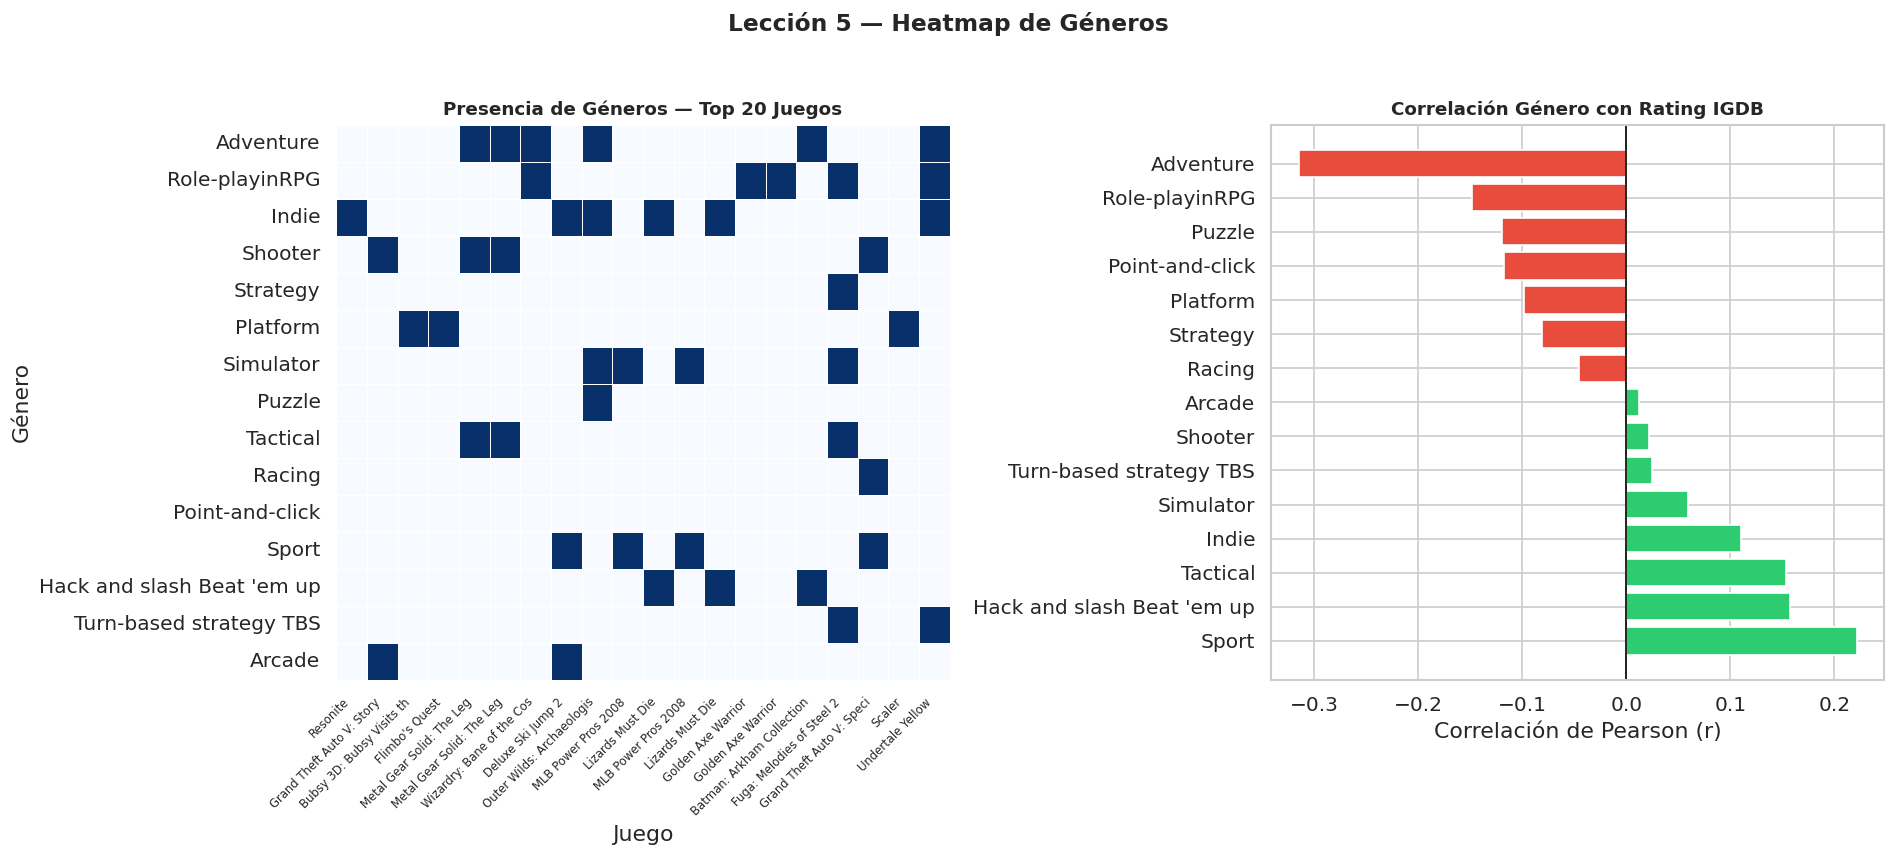

💾 Gráfico guardado: 09_heatmap_generos.png


In [26]:
# ─────────────────────────────────────────────
#  5.3 — HEATMAP: Géneros más frecuentes
# ─────────────────────────────────────────────

# Explotar géneros para análisis de frecuencia
all_genres_flat = [g for sublist in df['genres_list'] for g in sublist]
genre_freq = Counter(all_genres_flat)
top15_genres = [g for g, _ in genre_freq.most_common(15)]

# Matriz: para top géneros vs banda de rating
def tiene_genero(row, genero):
    return 1 if genero in row['genres_list'] else 0

for g in top15_genres:
    col = g.replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '')
    df[f'g_{col}'] = df.apply(lambda row: tiene_genero(row, g), axis=1)

g_cols = [c for c in df.columns if c.startswith('g_')]

# Correlación entre géneros y rating
genre_rating_corr = df[g_cols + ['igdb_rating']].corr()['igdb_rating'].drop('igdb_rating')
genre_rating_corr.index = [c.replace('g_', '').replace('_', ' ') for c in genre_rating_corr.index]
genre_rating_corr = genre_rating_corr.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap: presencia de géneros en top 20 juegos
df_top20 = df.head(20)
g_matrix = df_top20[g_cols].copy()
g_matrix.index = df_top20['name'].str[:25]  # Nombres truncados
g_matrix.columns = [c.replace('g_', '').replace('_', ' ') for c in g_cols]

sns.heatmap(g_matrix.T, cmap='Blues', linewidths=0.5, cbar=False,
            ax=axes[0], annot=False)
axes[0].set_title('Presencia de Géneros — Top 20 Juegos', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Juego')
axes[0].set_ylabel('Género')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=7)

# Barplot: correlación género vs rating
colors_corr = ['#e74c3c' if v < 0 else '#2ecc71' for v in genre_rating_corr.values]
axes[1].barh(genre_rating_corr.index, genre_rating_corr.values, color=colors_corr, edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('Correlación Género con Rating IGDB', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Correlación de Pearson (r)')

plt.suptitle('Lección 5 — Heatmap de Géneros', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_heatmap_generos.png', bbox_inches='tight')
plt.show()
print('💾 Gráfico guardado: 09_heatmap_generos.png')

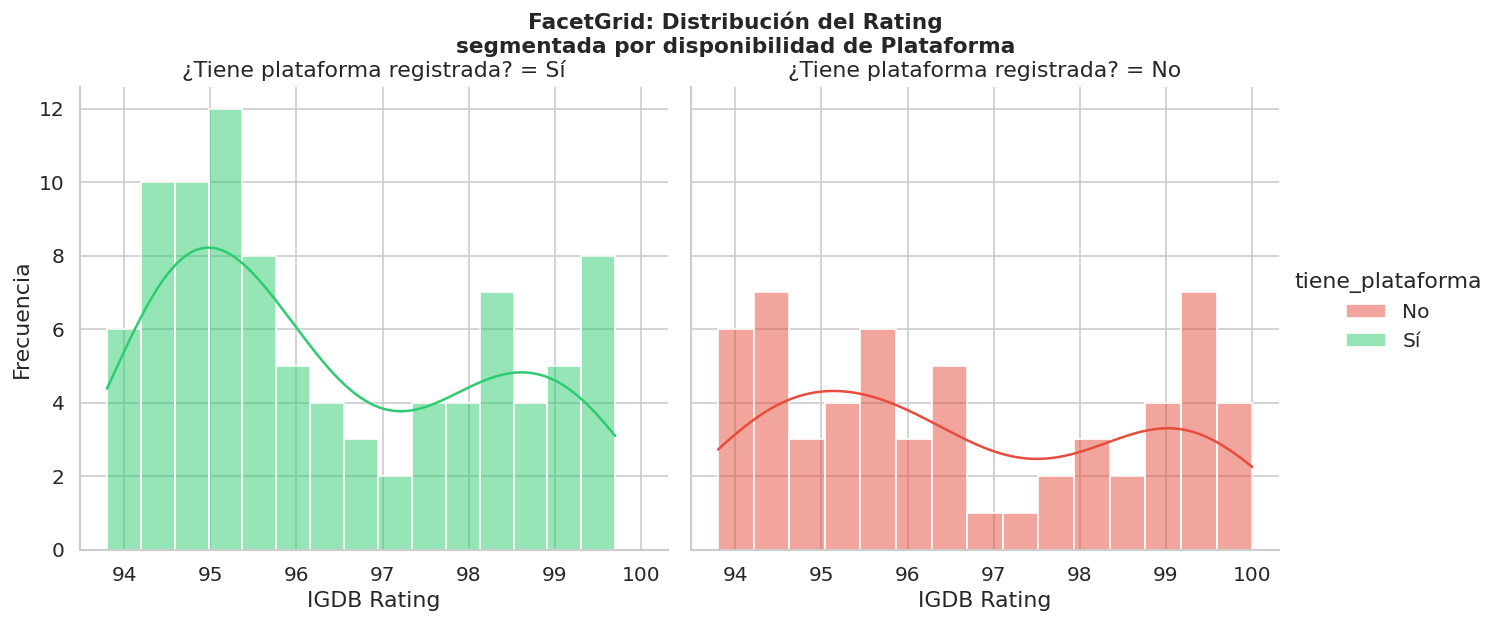

💾 Gráfico guardado: 10_facetgrid.png

📊 Rating por segmento (tiene_plataforma):
                  count   mean   std   min    max
tiene_plataforma                                 
No                   58  96.66  2.01  93.8  100.0
Sí                   92  96.39  1.84  93.8   99.7


In [27]:
# ─────────────────────────────────────────────
#  5.4 — FACETGRID: Distribución por Tiene Plataforma
# ─────────────────────────────────────────────
g = sns.FacetGrid(
    df, col='tiene_plataforma', hue='tiene_plataforma',
    palette={'Sí': '#2ecc71', 'No': '#e74c3c'},
    height=5, aspect=1.1, col_order=['Sí', 'No']
)
g.map(sns.histplot, 'igdb_rating', bins=15, kde=True, edgecolor='white')
g.set_axis_labels('IGDB Rating', 'Frecuencia')
g.set_titles('¿Tiene plataforma registrada? = {col_name}')
g.figure.suptitle('FacetGrid: Distribución del Rating\nsegmentada por disponibilidad de Plataforma',
                  fontsize=13, fontweight='bold', y=1.04)
g.add_legend()
g.figure.savefig(f'{OUTPUT_DIR}/10_facetgrid.png', bbox_inches='tight')
plt.show()
print('💾 Gráfico guardado: 10_facetgrid.png')

# Stats por grupo
print('\n📊 Rating por segmento (tiene_plataforma):')
print(df.groupby('tiene_plataforma')['igdb_rating']
      .agg(['count', 'mean', 'std', 'min', 'max'])
      .round(2).to_string())

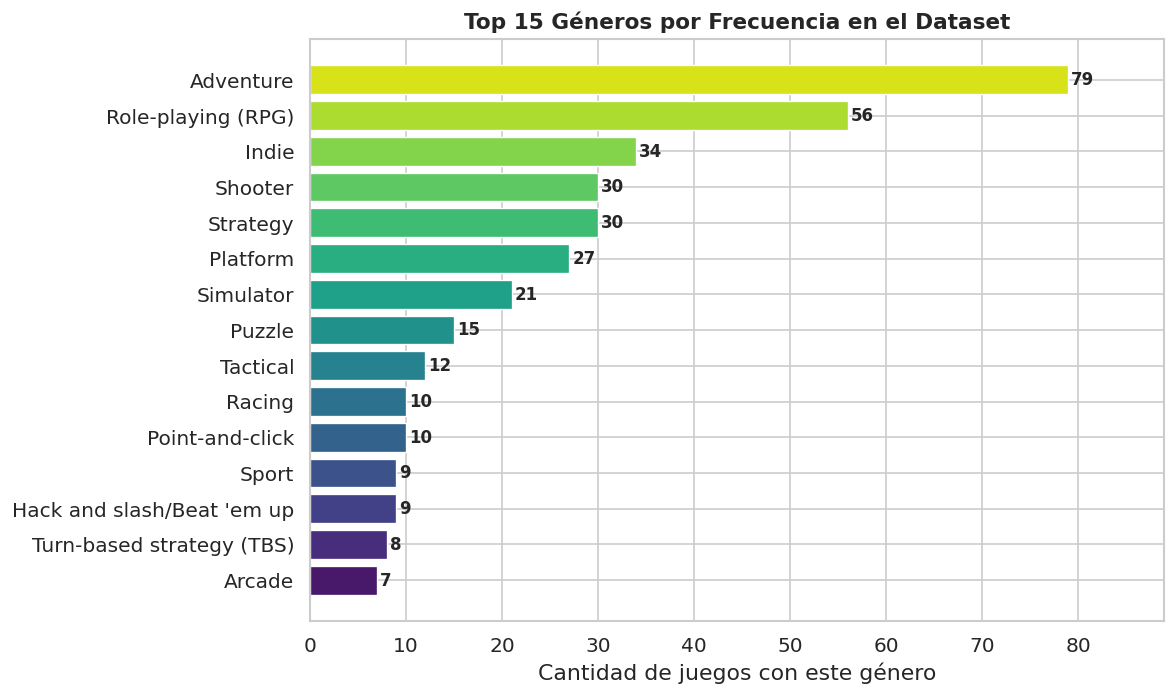

💾 Gráfico guardado: 11_top_generos.png


In [28]:
# ─────────────────────────────────────────────
#  5.5 — TOP 15 GÉNEROS (frecuencia)
# ─────────────────────────────────────────────
genre_df = pd.DataFrame(genre_freq.most_common(15), columns=['Género', 'Frecuencia'])

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('viridis', len(genre_df))
bars = ax.barh(genre_df['Género'][::-1], genre_df['Frecuencia'][::-1],
               color=palette, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, genre_df['Frecuencia'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold', fontsize=10)
ax.set_title('Top 15 Géneros por Frecuencia en el Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Cantidad de juegos con este género')
ax.set_xlim(0, genre_df['Frecuencia'].max() + 10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_top_generos.png', bbox_inches='tight')
plt.show()
print('💾 Gráfico guardado: 11_top_generos.png')

---
# 🖼️ LECCIÓN 6 — Librería Matplotlib: Visualizaciones Finales
> **Objetivo:** Crear figuras y subplots personalizados. Personalizar títulos, etiquetas, leyendas, ticks, anotaciones. Generar presentación visual de resultados.

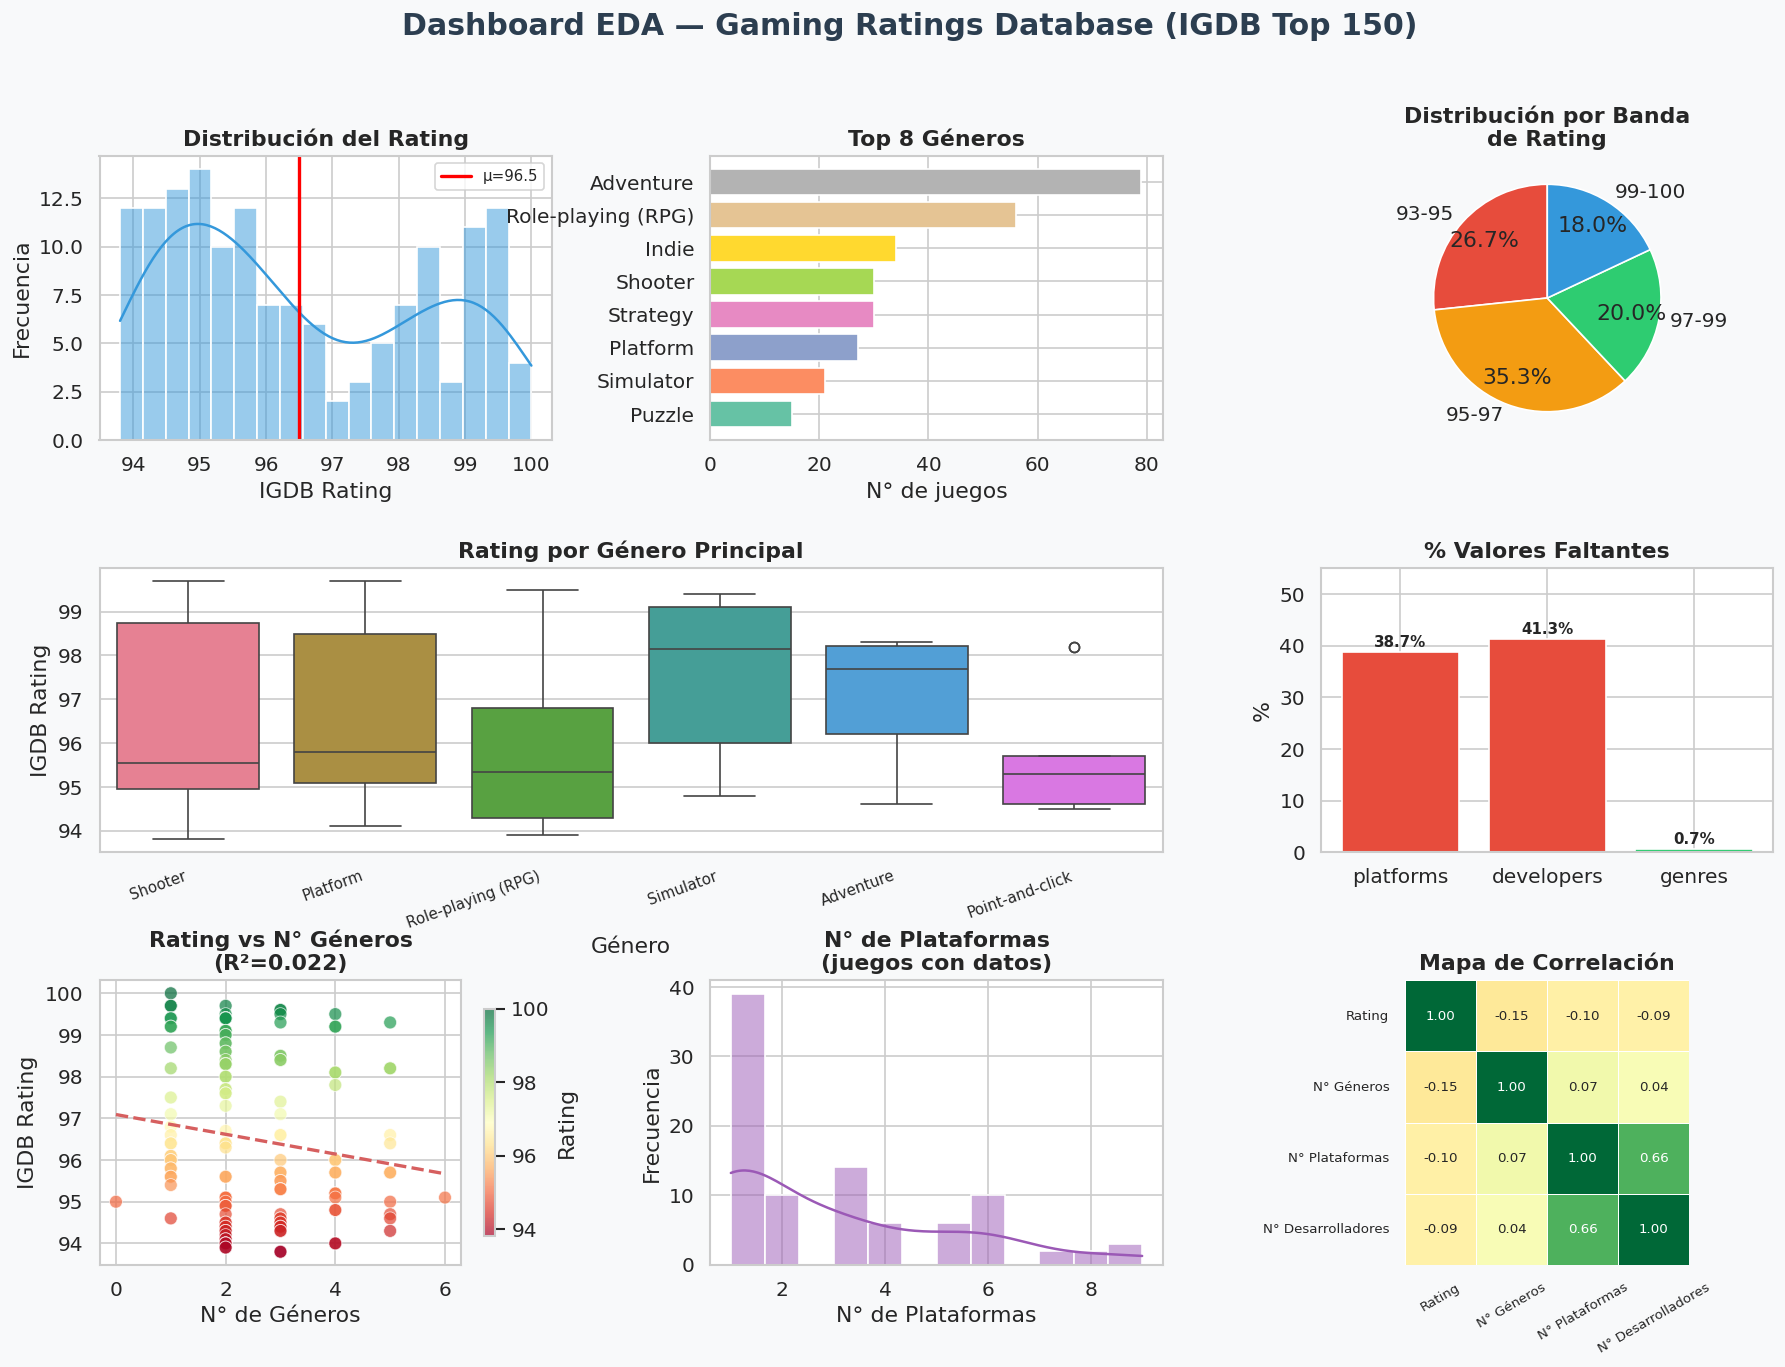

💾 Gráfico guardado: 12_dashboard_ejecutivo.png


In [29]:
# ─────────────────────────────────────────────
#  6.1 — DASHBOARD EJECUTIVO (figura con subplots)
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#f8f9fa')

# Título principal
fig.suptitle('Dashboard EDA — Gaming Ratings Database (IGDB Top 150)',
             fontsize=18, fontweight='bold', y=0.98, color='#2c3e50')

# Layout de subplots
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ── Subplot 1: Histograma de rating
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(df['igdb_rating'], bins=18, kde=True, color='#3498db',
             edgecolor='white', ax=ax1)
ax1.axvline(df['igdb_rating'].mean(), color='red', lw=2,
            label=f'μ={df["igdb_rating"].mean():.1f}')
ax1.set_title('Distribución del Rating', fontweight='bold')
ax1.set_xlabel('IGDB Rating')
ax1.set_ylabel('Frecuencia')
ax1.legend(fontsize=9)

# ── Subplot 2: Top géneros
ax2 = fig.add_subplot(gs[0, 1])
top8 = pd.DataFrame(genre_freq.most_common(8), columns=['Género', 'N'])
colors8 = sns.color_palette('Set2', 8)
ax2.barh(top8['Género'][::-1], top8['N'][::-1], color=colors8, edgecolor='white')
ax2.set_title('Top 8 Géneros', fontweight='bold')
ax2.set_xlabel('N° de juegos')

# ── Subplot 3: Pie chart de bandas de rating
ax3 = fig.add_subplot(gs[0, 2])
band_counts2 = df['rating_band'].value_counts().sort_index()
wedges, texts, autotexts = ax3.pie(
    band_counts2.values,
    labels=band_counts2.index.astype(str),
    autopct='%1.1f%%',
    colors=['#e74c3c', '#f39c12', '#2ecc71', '#3498db'],
    startangle=90,
    pctdistance=0.75
)
ax3.set_title('Distribución por Banda\nde Rating', fontweight='bold')

# ── Subplot 4: Boxplot por género
ax4 = fig.add_subplot(gs[1, :2])
top6 = df['genre_primary'].value_counts().head(6).index.tolist()
df6  = df[df['genre_primary'].isin(top6)]
sns.boxplot(data=df6, x='genre_primary', y='igdb_rating',
            palette='husl', ax=ax4)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=20, ha='right', fontsize=9)
ax4.set_title('Rating por Género Principal', fontweight='bold')
ax4.set_xlabel('Género')
ax4.set_ylabel('IGDB Rating')

# ── Subplot 5: Valores faltantes
ax5 = fig.add_subplot(gs[1, 2])
null_data = {'platforms': 38.7, 'developers': 41.3, 'genres': 0.7}
colors_null = ['#e74c3c', '#e74c3c', '#2ecc71']
ax5.bar(null_data.keys(), null_data.values(), color=colors_null, edgecolor='white')
ax5.set_title('% Valores Faltantes', fontweight='bold')
ax5.set_ylabel('%')
ax5.set_ylim(0, 55)
for i, (k, v) in enumerate(null_data.items()):
    ax5.text(i, v + 1, f'{v}%', ha='center', fontweight='bold', fontsize=9)

# ── Subplot 6: Scatter Rating vs N géneros
ax6 = fig.add_subplot(gs[2, 0])
sc = ax6.scatter(df['n_genres'], df['igdb_rating'],
                 c=df['igdb_rating'], cmap='RdYlGn',
                 alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
fig.colorbar(sc, ax=ax6, shrink=0.8, label='Rating')
m2, b2 = np.polyfit(df['n_genres'], df['igdb_rating'], 1)
x_r = np.linspace(0, df['n_genres'].max(), 100)
ax6.plot(x_r, m2*x_r + b2, 'r--', lw=2)
ax6.set_title(f'Rating vs N° Géneros\n(R²={r2_s:.3f})', fontweight='bold')
ax6.set_xlabel('N° de Géneros')
ax6.set_ylabel('IGDB Rating')

# ── Subplot 7: Distribución N° plataformas
ax7 = fig.add_subplot(gs[2, 1])
df_con_plat = df[df['n_platforms'] > 0]
sns.histplot(df_con_plat['n_platforms'], bins=12, color='#9b59b6',
             edgecolor='white', kde=True, ax=ax7)
ax7.set_title('N° de Plataformas\n(juegos con datos)', fontweight='bold')
ax7.set_xlabel('N° de Plataformas')
ax7.set_ylabel('Frecuencia')

# ── Subplot 8: Heatmap correlación
ax8 = fig.add_subplot(gs[2, 2])
corr_mini = df_num[['Rating', 'N° Géneros', 'N° Plataformas', 'N° Desarrolladores']].corr()
sns.heatmap(corr_mini, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar=False, ax=ax8, square=True, annot_kws={'fontsize': 8})
ax8.set_title('Mapa de Correlación', fontweight='bold')
ax8.tick_params(axis='x', rotation=30, labelsize=8)
ax8.tick_params(axis='y', rotation=0, labelsize=8)

plt.savefig(f'{OUTPUT_DIR}/12_dashboard_ejecutivo.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('💾 Gráfico guardado: 12_dashboard_ejecutivo.png')

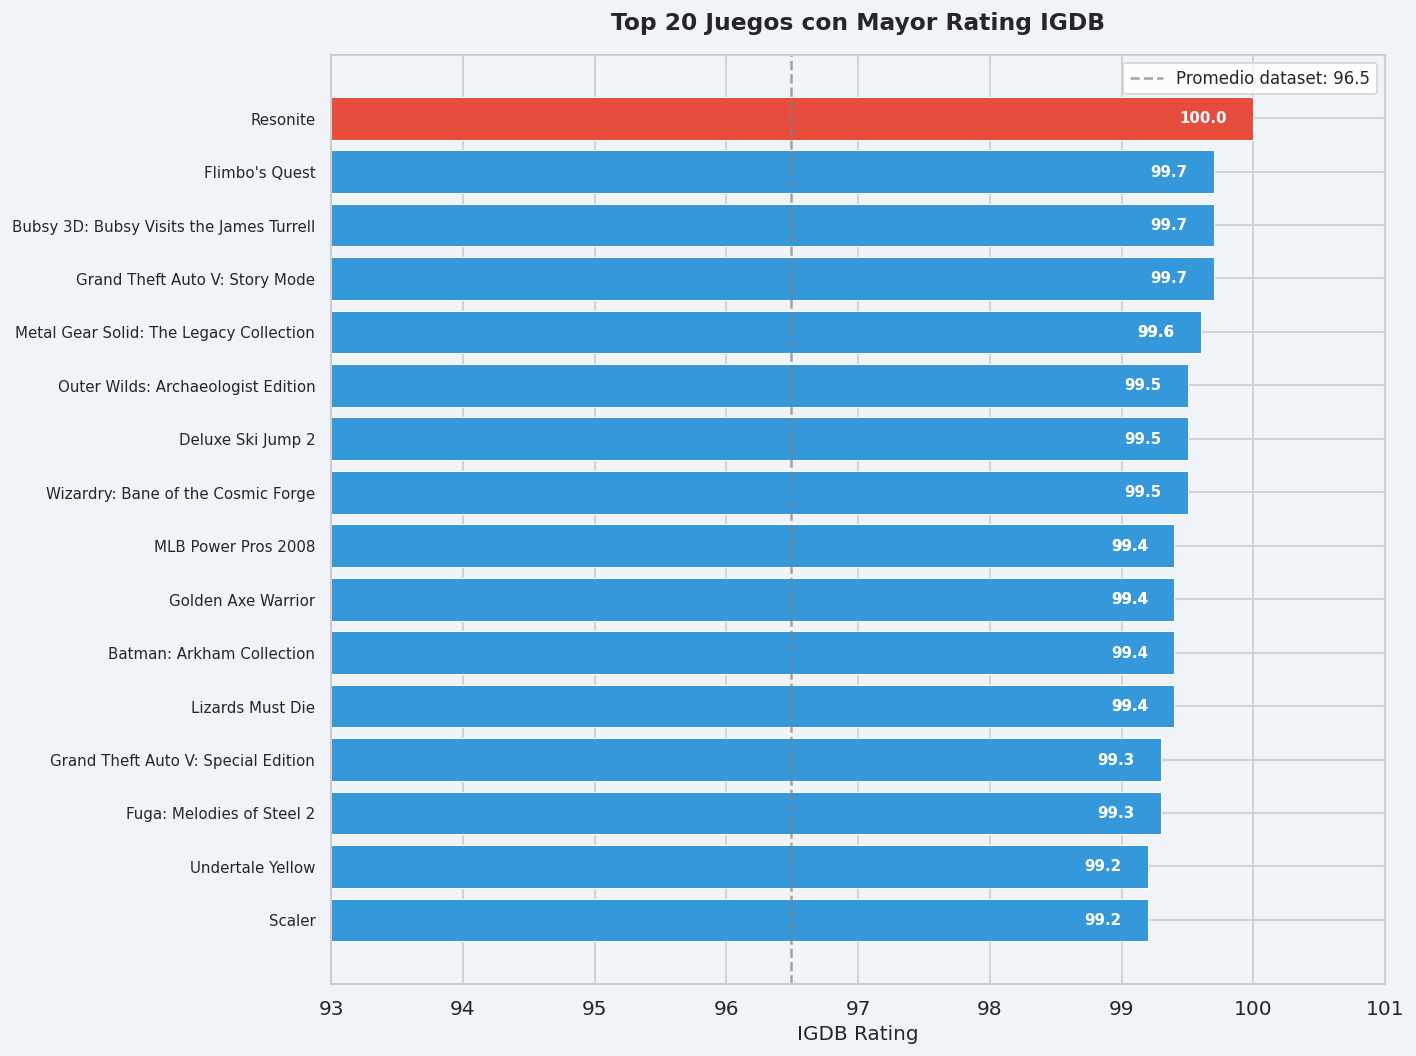

💾 Gráfico guardado: 13_top20_juegos.png


In [30]:
# ─────────────────────────────────────────────
#  6.2 — GRÁFICO DE TOP 20 JUEGOS (Anotaciones)
# ─────────────────────────────────────────────
df_top20_plot = df.head(20).sort_values('igdb_rating')

fig, ax = plt.subplots(figsize=(12, 9))
ax.set_facecolor('#f0f4f8')
fig.patch.set_facecolor('#f0f4f8')

colors_top = ['#e74c3c' if r == 100 else '#3498db' for r in df_top20_plot['igdb_rating']]
bars = ax.barh(df_top20_plot['name'].str[:40],
               df_top20_plot['igdb_rating'],
               color=colors_top, edgecolor='white', linewidth=0.6)

# Etiquetas de rating
for bar, val in zip(bars, df_top20_plot['igdb_rating']):
    ax.text(bar.get_width() - 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', ha='right', color='white',
            fontweight='bold', fontsize=9)

# Anotación especial al juego #1
top_game = df_top20_plot.iloc[-1]
ax.annotate(f'⭐ TOP 1: {top_game["igdb_rating"]}',
            xy=(top_game['igdb_rating'], len(df_top20_plot)-1),
            xytext=(96, len(df_top20_plot)-0.5),
            fontsize=10, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2))

ax.set_xlim(93, 101)
ax.set_xlabel('IGDB Rating', fontsize=12)
ax.set_title('Top 20 Juegos con Mayor Rating IGDB', fontsize=14, fontweight='bold', pad=15)
ax.axvline(df['igdb_rating'].mean(), color='gray', linestyle='--', alpha=0.7,
           label=f'Promedio dataset: {df["igdb_rating"].mean():.1f}')
ax.legend(fontsize=10)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/13_top20_juegos.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('💾 Gráfico guardado: 13_top20_juegos.png')

In [31]:
# ─────────────────────────────────────────────
#  6.3 — RESUMEN DE GRÁFICOS EXPORTADOS
# ─────────────────────────────────────────────
import glob
graficos = sorted(glob.glob(f'{OUTPUT_DIR}/*.png'))
print(f'📁 GRÁFICOS EXPORTADOS EN /{OUTPUT_DIR}/')
print('═' * 55)
for g in graficos:
    size = os.path.getsize(g) / 1024
    print(f'  {os.path.basename(g):<45} ({size:.0f} KB)')
print('═' * 55)
print(f'  Total: {len(graficos)} archivos')

📁 GRÁFICOS EXPORTADOS EN /graficos_exportados/
═══════════════════════════════════════════════════════
  01_valores_faltantes.png                      (47 KB)
  02_histograma_rating.png                      (98 KB)
  03_boxplots.png                               (95 KB)
  04_correlaciones.png                          (175 KB)
  05_pairplot.png                               (208 KB)
  06_regresion.png                              (226 KB)
  07_violinplot.png                             (124 KB)
  08_jointplot.png                              (66 KB)
  09_heatmap_generos.png                        (181 KB)
  10_facetgrid.png                              (77 KB)
  11_top_generos.png                            (76 KB)
  12_dashboard_ejecutivo.png                    (350 KB)
  13_top20_juegos.png                           (129 KB)
═══════════════════════════════════════════════════════
  Total: 13 archivos


---
# 📋 RESUMEN EJECUTIVO — Hallazgos y Recomendaciones

## 🔍 Hallazgos Principales

### Dataset
- **150 juegos** con ratings IGDB entre 93.8 y 100 — representan la élite global
- **Columna `release_year` corrupta**: contiene la primera palabra del nombre del juego (artefacto de generación del CSV) → documentado como hallazgo IDA crítico
- Alta tasa de nulos en `platforms` (38.7%) y `developers` (41.3%)

### Estadística Descriptiva
- Rating promedio: **96.49 ± 1.90** → distribución compacta y homogénea
- Coeficiente de variación: **~2%** → todos los juegos son excepcionalmente bien valorados
- **Sin outliers** por método IQR: consistente con ser un dataset de élite

### Correlaciones
- Todas las correlaciones con el rating son **débiles** (|r| < 0.3)
- La correlación entre `n_developers` y `tiene_plataforma` es espuria: ambas dependen de completitud de metadatos en IGDB
- **Adventure** y **Role-playing (RPG)** son los géneros más frecuentes

### Regresión
- Modelos con R² < 0.05: las variables disponibles **no predicen** el rating de forma útil
- Insight estratégico: la calidad de un juego élite no depende del número de géneros/plataformas

## 💡 Recomendaciones

1. **Corregir el dataset**: La columna `release_year` requiere ser regenerada desde la fuente IGDB para habilitar análisis temporales
2. **Enriquecer con más variables**: Precio, horas de juego, reseñas de usuarios, fecha de lanzamiento real → mejoraría drásticamente el poder predictivo
3. **Ampliar el dataset**: Incluir juegos de rating < 93 permitiría estudiar qué diferencia a los mejores del promedio
4. **Análisis por género**: Los géneros con mayor variabilidad de rating son los más interesantes para decisiones comerciales (targeting)
5. **Completar metadatos**: El 40% de juegos sin plataforma/desarrollador limita análisis de mercado — se recomienda completar vía API de IGDB